<a href="https://colab.research.google.com/github/Shuhan78/news_index_and_predict/blob/main/stock_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 正在準備繁體中文字型...
🔍 開始搜尋股票代號: 2308 ...
✅ 成功獲取 台達電 (2308) 的資料！(市場別: 上市 (TSE))

📰 開始嘗試透過 Google RSS 獲取【台達電 (2308)】的新聞 ...


/tmp/ipykernel_3763/3660614862.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_temp = yf.download(f"{stock_id}{suffix}", period="1mo", progress=False)


✅ 成功取得 100 則新聞
⏳ 載入 AI 零樣本分類模型中...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

...

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

🧠 正在客觀判定新聞字面情緒...


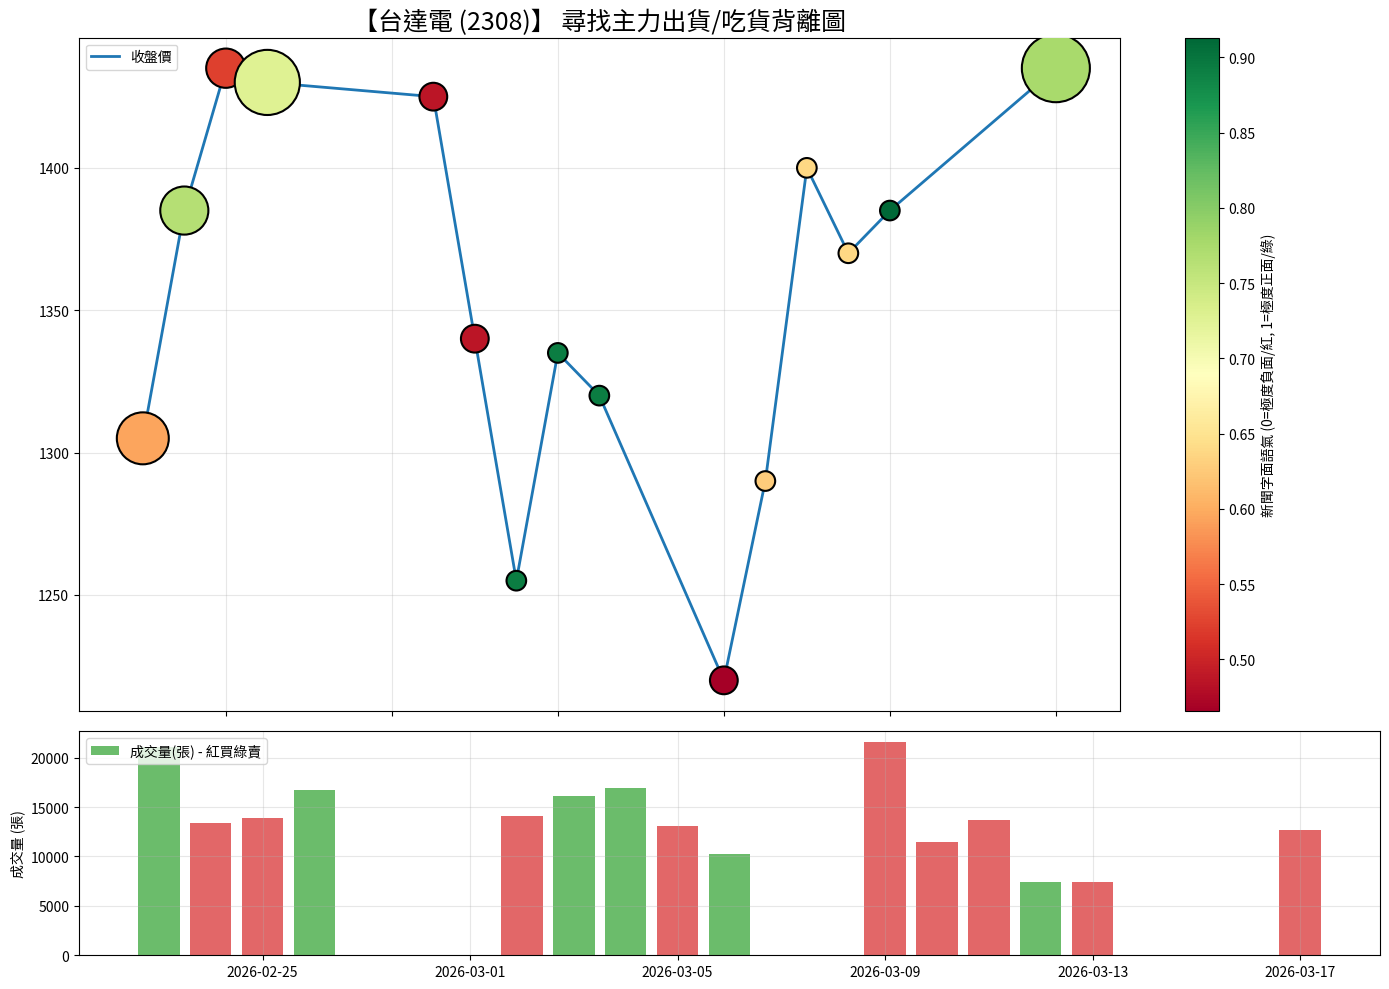


--- 📝 台達電 (2308) 新聞情緒客觀摘要 (前 5 筆) ---
           日期                                               新聞標題    正面報導機率
0  2026-03-17     台達電 55 週年論壇登場，創辦人鄭崇華與國際專家談能源新局 - TechNews 科技新報  0.881920
1  2026-03-17               24檔「黃仁勳背板股」發威！台達電技嘉飆逾5%最亮眼 - Yahoo股市  0.877739
2  2026-03-17  【台股盤前0317】GTC大會正式開跑! LPU可望率先推出? 「法說會前股價延續」聚焦: ...  0.672332
3  2026-03-13  杜金龍8點45分搶進台積電、台達電狂賺百元！旺宏、群創、鴻海可以撿？當沖秘訣曝光！看好這檔金...  0.913233
4  2026-02-26  台達電繳史上最強財報！2025淨利601億「年增70%」：AI資料中心大爆發，全球產能緊繃了...  0.951701


In [2]:
# 1. 安裝所需套件
!pip install -q yfinance feedparser transformers torch

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from datetime import datetime, timedelta
import feedparser
import time
import sys

from transformers import pipeline

# ==========================================
# 🔧 0. 環境準備：中文字型
# ==========================================
print("📥 正在準備繁體中文字型...")
!wget -q -O NotoSansTC.otf https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

fm.fontManager.addfont("NotoSansTC.otf")
font_prop = fm.FontProperties(fname="NotoSansTC.otf")
plt.rcParams['font.sans-serif'] = [font_prop.get_name()]
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# ⚙️ 1. 設定參數區 (全域變數)
# ==========================================
stock_id = "2308"      # 這裡設定代號
stock_name = "台達電"  # 這裡設定名稱

# ==========================================
# 📈 2. 智慧抓取股價 (加入 Open 開盤價以計算紅綠量)
# ==========================================
# ✅ 確定有放入 stock_id
print(f"🔍 開始搜尋股票代號: {stock_id} ...")

market_type = ""
ticker_id = ""
df_price_raw = pd.DataFrame()

# 測試上市與上櫃
for suffix, m_type in [(".TW", "上市 (TSE)"), (".TWO", "上櫃/興櫃 (OTC/Emerging)")]:
    df_temp = yf.download(f"{stock_id}{suffix}", period="1mo", progress=False)
    if not df_temp.empty:
        df_price_raw = df_temp
        market_type = m_type
        ticker_id = f"{stock_id}{suffix}"
        break

if df_price_raw.empty:
    print(f"\n❌ [錯誤] 查無此股票價格！(代號: {stock_id})")
    sys.exit("程式已終止。")

print(f"✅ 成功獲取 {stock_name} ({stock_id}) 的資料！(市場別: {market_type})")

# 提取所需欄位
if isinstance(df_price_raw.columns, pd.MultiIndex):
    df_price = pd.DataFrame({
        'Open': df_price_raw['Open'].squeeze(),
        'Close': df_price_raw['Close'].squeeze(),
        'Volume': df_price_raw['Volume'].squeeze()
    })
else:
    df_price = df_price_raw[['Open', 'Close', 'Volume']].copy()

df_price.index = pd.to_datetime(df_price.index).tz_localize(None)

# 計算台股成交量顏色 (收盤 >= 開盤 為紅柱，反之為綠柱)
df_price['Volume_Color'] = np.where(df_price['Close'] >= df_price['Open'], '#d62728', '#2ca02c')

# ==========================================
# 📰 3. 抓取新聞 (Google RSS)
# ==========================================
# ✅ 修復點：補回 news_list 的初始化！
news_list = []

print(f"\n📰 開始嘗試透過 Google RSS 獲取【{stock_name} ({stock_id})】的新聞 ...")

rss_url = f"https://news.google.com/rss/search?q={stock_name}&hl=zh-TW&gl=TW&ceid=TW:zh-Hant"
feed = feedparser.parse(rss_url)

for entry in feed.entries:
    try:
        dt_struct = entry.published_parsed
        dt = datetime.fromtimestamp(time.mktime(dt_struct))
        if dt.weekday() == 5: dt += timedelta(days=2)
        elif dt.weekday() == 6: dt += timedelta(days=1)
        news_list.append({'date': dt.strftime('%Y-%m-%d'), 'title': entry.title})
    except:
        continue

df_news = pd.DataFrame(news_list)
if not df_news.empty:
    print(f"✅ 成功取得 {len(df_news)} 則新聞")

    # ==========================================
    # 🧠 4. 進階 AI：回歸客觀的「正面/負面報導」判定
    # ==========================================
    print("⏳ 載入 AI 零樣本分類模型中...")
    classifier = pipeline("zero-shot-classification", model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=-1)

    def analyze_objective_sentiment(text):
        try:
            labels = ["正面報導", "負面報導"]
            result = classifier(text[:512], candidate_labels=labels)
            pos_index = result['labels'].index("正面報導")
            return result['scores'][pos_index]
        except:
            return 0.5

    print("🧠 正在客觀判定新聞字面情緒...")
    df_news['sentiment'] = df_news['title'].apply(analyze_objective_sentiment)

    daily_news = df_news.groupby('date').agg({'sentiment': ['mean', 'count']})
    daily_news.columns = ['avg_sentiment', 'news_count']
    daily_news.index = pd.to_datetime(daily_news.index)

    final_df = pd.merge_asof(df_price.sort_index(), daily_news.sort_index(),
                             left_index=True, right_index=True,
                             direction='backward')
    final_df['news_count'] = final_df['news_count'].fillna(0)
    final_df['avg_sentiment'] = final_df['avg_sentiment'].fillna(0.5)

    # ==========================================
    # 🎨 5. 繪圖：捕捉「新聞與籌碼背離」的瞬間
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                   gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # --- 上半部 (ax1)：股價與新聞情緒泡泡 ---
    ax1.plot(final_df.index, final_df['Close'], color='#1f77b4', label='收盤價', linewidth=2)

    news_days = final_df[final_df['news_count'] > 0]
    if not news_days.empty:
        scatter = ax1.scatter(news_days.index, news_days['Close'],
                              c=news_days['avg_sentiment'], cmap='RdYlGn',
                              s=news_days['news_count'] * 200,
                              edgecolors='black', linewidth=1.5, zorder=5)
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('新聞字面語氣 (0=極度負面/紅, 1=極度正面/綠)')

    ax1.set_title(f"【{stock_name} ({stock_id})】 尋找主力出貨/吃貨背離圖", fontsize=18, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # --- 下半部 (ax2)：帶有紅綠買賣盤判定的成交量 ---
    final_df['Volume_Lots'] = final_df['Volume'] / 1000

    ax2.bar(final_df.index, final_df['Volume_Lots'],
            color=final_df['Volume_Color'], alpha=0.7, label='成交量(張) - 紅買綠賣')

    ax2.set_ylabel('成交量 (張)')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n--- 📝 {stock_name} ({stock_id}) 新聞情緒客觀摘要 (前 5 筆) ---")
    df_news_display = df_news.rename(columns={'date': '日期', 'title': '新聞標題', 'sentiment': '正面報導機率'})
    print(df_news_display.head())
else:
    print(f"⚠️ 沒抓到關於【{stock_name} ({stock_id})】的新聞。")